In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os
from pathlib import Path
from datetime import datetime
from scipy.stats import lognorm

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)


from src.pipeline.calculate_evs import *
from src.utils.helper_functions import *
from src.features.ngboost_points import *
from src.features.feature_engine import FeatureEngine
from src.utils.team_info import teamStarPlayer, projectedStartingFive, mainStartingFive
from src.models.ngboost_model import predict_mean
from src.pipeline.pipeline_pts import build_ngboost_points_features

/Users/alexgonzalez/Documents/NBA-Prop-Predictor/nba_model/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.set_option('display.max_columns', None)
today = datetime.today().strftime('%Y%m%d')  
current_date = datetime.now().strftime('%Y-%m-%d')

def get_latest_file(pattern):
    files = list(Path('data/raw/player_lines').glob(pattern))
    if not files:
        return None
    return max(files, key=lambda p: p.stat().st_mtime)

us_file = get_latest_file(f'NBA_US_{today}*.csv')
dfs_file = get_latest_file(f'NBA_DFS_{today}*.csv')

if us_file is None:
    raise FileNotFoundError(f"No NBA_US file found for {today}")
if dfs_file is None:
    raise FileNotFoundError(f"No NBA_DFS file found for {today}")

s26 = pd.read_csv('data/processed/training/PTS_TRAIN_26.csv').sort_values(by='GAME_DATE')
usData = pd.read_csv(us_file)
dfsData = pd.read_csv(dfs_file)

print(f"Loaded: {us_file.name}")
print(f"Loaded: {dfs_file.name}")
dfsData.head()

Loaded: NBA_US_20251208_142444.csv
Loaded: NBA_DFS_20251208_142406.csv


,BOOKMAKER,CATEGORY,NAME,OVER/UNDER,LINE,ODDS,COMMENCE_TIME,LAST_UPDATE,DATA_PULLED_AT
0,Underdog,player_points,Pascal Siakam,Over,24.5,-137,2025-12-09,2025-12-08T22:23:21Z,2025-12-08 14:24:06
1,Underdog,player_points,Pascal Siakam,Under,24.5,-137,2025-12-09,2025-12-08T22:23:21Z,2025-12-08 14:24:06
2,Underdog,player_points,Zach LaVine,Over,21.5,-137,2025-12-09,2025-12-08T22:23:21Z,2025-12-08 14:24:06
3,Underdog,player_points,Zach LaVine,Under,21.5,-137,2025-12-09,2025-12-08T22:23:21Z,2025-12-08 14:24:06
4,Underdog,player_points,Andrew Nembhard,Over,16.5,-137,2025-12-09,2025-12-08T22:23:21Z,2025-12-08 14:24:06


In [3]:
# dfsData = pd.read_csv('data/raw/player_lines/NBA_DFS_20251206_134221.csv')
# usData = pd.read_csv('data/raw/player_lines/NBA_US_20251206_134342.csv')
# s26 = pd.read_csv('data/processed/training/PTS_TRAIN_26.csv').sort_values(by='GAME_DATE')

In [15]:
name = 'Andrew Nembhard'
betting_line = 16.5 
odds = -137

engine = FeatureEngine({
    "min_model": "src/models/saved/min_model.pkl",
    "usg_model": "src/models/saved/usg_model.pkl",
    "fga_model": "src/models/saved/fga_model.pkl",
    "ngboost_model_wrapper": "src/models/saved/pts_model_wrapper.pkl"
})

# Get prediction
result = engine.project_player(
    player_name=name,
    data=s26,
    date="2025-12-07",
    projectedStartingFive=projectedStartingFive,
    mainStartingFive=mainStartingFive,
    teamStarPlayer=teamStarPlayer,
    league_df=league_df,
    findOpp=findOpp
)

print("Prediction Result:")
print(f"  Predicted Minutes: {result['predicted_minutes']:.2f}")
print(f"  Predicted Usage: {result['predicted_usage']:.3f}")
print(f"  Predicted FGA: {result['predicted_fga']:.2f}")
print(f"  Predicted Points: {result['predicted_points']:.2f}")

Prediction Result:
  Predicted Minutes: 28.59
  Predicted Usage: 0.217
  Predicted FGA: 12.06
  Predicted Points: 18.22


In [16]:
# Create log-normal distribution using calibrations
if engine.ngboost_model_wrapper:
    # Get the model and features
    mean_model = engine.ngboost_model_wrapper['mean_model']
    features_list = engine.ngboost_model_wrapper['features']
    variance_calibration = engine.ngboost_model_wrapper.get('variance_calibration')
    bins = engine.ngboost_model_wrapper.get('bins')
    
    median_pred = result['predicted_points']
    
    feature_dict = build_ngboost_points_features(
        player_name=name,
        data=s26,
        current_date="2025-12-06",
        projectedStartingFive=projectedStartingFive,
        mainStartingFive=mainStartingFive,
        teamStarPlayer=teamStarPlayer,
        league_df=league_df,
        findOpp=findOpp,
        predicted_minutes=result['predicted_minutes'],
        predicted_usage=result['predicted_usage']
    )
    
    if feature_dict:
        feature_vector = [feature_dict.get(f, 0.0) for f in features_list]
        feature_df = pd.DataFrame([feature_vector], columns=features_list)
        feature_df = feature_df.replace([np.inf, -np.inf], np.nan)
        
        # Get distribution parameters
        dist = mean_model.pred_dist(feature_df[features_list].fillna(feature_df[features_list].median()))
        mean_log = float(dist.loc[0])
        scale_log = float(dist.scale[0])
        var_log = scale_log ** 2
        
        # Apply calibrations based on bins
        if variance_calibration and bins:
            low_bin, medium_bin, high_bin = bins[0], bins[1], bins[2]
            if (median_pred >= low_bin[0]) and (median_pred < low_bin[1]):
                var_log *= variance_calibration.get('low', 1.0)
                print(f"\nUsing LOW bin calibration: {variance_calibration.get('low')}")
            elif (median_pred >= medium_bin[0]) and (median_pred < medium_bin[1]):
                var_log *= variance_calibration.get('medium', 1.0)
                print(f"\nUsing MEDIUM bin calibration: {variance_calibration.get('medium')}")
            elif (median_pred >= high_bin[0]) and (median_pred < high_bin[1]):
                var_log *= variance_calibration.get('high', 1.0)
                print(f"\nUsing HIGH bin calibration: {variance_calibration.get('high')}")
        
        std_log = np.sqrt(var_log)
        distribution = lognorm(s=std_log, scale=np.exp(mean_log))
        
        print(f"\nLog-Normal Distribution Parameters:")
        print(f"  Mean (log space): {mean_log:.4f}")
        print(f"  Std (log space): {std_log:.4f}")
        print(f"  Median: {median_pred:.2f}")
        print(f"  Mean: {distribution.mean():.2f}")
        print(f"  Std: {distribution.std():.2f}")
        
        samples = distribution.rvs(size=10000)
        print(f"\nDistribution Statistics (from samples):")
        print(f"  5th percentile: {np.percentile(samples, 5):.2f}")
        print(f"  25th percentile: {np.percentile(samples, 25):.2f}")
        print(f"  50th percentile (median): {np.percentile(samples, 50):.2f}")
        print(f"  75th percentile: {np.percentile(samples, 75):.2f}")
        print(f"  95th percentile: {np.percentile(samples, 95):.2f}")
        
        # Monte Carlo Simulation
        print("\n" + "="*60)
        print("MONTE CARLO SIMULATION")
        print("="*60)
        
        # Create test lines in 0.5 intervals around betting line
        betting_line_rounded = round(betting_line * 2) / 2
        num_lines_below = 2  # 4 * 0.5 = 2.0 points below
        num_lines_above = 2  # 4 * 0.5 = 2.0 points above
        
        test_lines = []
        for i in range(-num_lines_below, num_lines_above + 1):
            test_line = betting_line_rounded + (i * 0.5)
            if test_line > 0:
                test_lines.append(test_line)
        
        # Ensure actual betting line is included
        if betting_line not in test_lines:
            test_lines.append(betting_line)
        
        test_lines = sorted(set(test_lines))
        
        # Convert odds to decimal
        if odds > 0:
            dec_odds = 1 + (odds / 100.0)
        else:
            dec_odds = 1 + (100.0 / abs(odds))
        
        print(f"\nTesting {len(samples):,} simulations against different lines:")
        print(f"Predicted Median: {median_pred:.2f} points")
        print(f"Betting Line: {betting_line:.1f} points | Odds: {odds:+d} ({dec_odds:.3f} decimal)")
        print(f"Test Lines: {[f'{l:.1f}' for l in test_lines]}\n")
        
        results = []
        for test_line in test_lines:
            # Calculate probabilities - these should sum to 100%
            prob_over = 1 - distribution.cdf(test_line)
            prob_under = distribution.cdf(test_line)
            
            # Monte Carlo: count wins (for validation)
            over_wins = np.sum(samples > test_line)
            under_wins = np.sum(samples <= test_line)
            over_rate = over_wins / len(samples)
            under_rate = under_wins / len(samples)
            
            # Calculate expected value using actual odds
            ev_over = (prob_over * (dec_odds - 1)) - (1 - prob_over)
            ev_under = (prob_under * (dec_odds - 1)) - (1 - prob_under)
            
            results.append({
                'Line': test_line,
                'Prob_Over': prob_over,
                'Prob_Under': prob_under,
                'MC_Over_Rate': over_rate,
                'MC_Under_Rate': under_rate,
                'EV_Over': ev_over,
                'EV_Under': ev_under
            })
            
            # Determine best bet
            if ev_over > ev_under and ev_over > 0:
                best_bet = f"OVER {test_line:.1f} (EV: {ev_over:+.3f})"
            elif ev_under > ev_over and ev_under > 0:
                best_bet = f"UNDER {test_line:.1f} (EV: {ev_under:+.3f})"
            else:
                best_bet = "No positive EV"
            
            # Highlight the actual betting line
            line_marker = " <-- BETTING LINE" if abs(test_line - betting_line) < 0.01 else ""
            print(f"Line: {test_line:.1f}{line_marker}")
            print(f"  Over: {prob_over:.1%} (MC: {over_rate:.1%}) | EV: {ev_over:+.3f}")
            print(f"  Under: {prob_under:.1%} (MC: {under_rate:.1%}) | EV: {ev_under:+.3f}")
            print(f"  Sum: {(prob_over + prob_under):.1%}")  # Should be 100%
            print(f"  → {best_bet}\n")


Using HIGH bin calibration: 0.95

Log-Normal Distribution Parameters:
  Mean (log space): 2.9560
  Std (log space): 0.3279
  Median: 18.22
  Mean: 20.28
  Std: 6.83

Distribution Statistics (from samples):
  5th percentile: 11.14
  25th percentile: 15.26
  50th percentile (median): 19.18
  75th percentile: 23.95
  95th percentile: 32.70

MONTE CARLO SIMULATION

Testing 10,000 simulations against different lines:
Predicted Median: 18.22 points
Betting Line: 16.5 points | Odds: -137 (1.730 decimal)
Test Lines: ['15.5', '16.0', '16.5', '17.0', '17.5']

Line: 15.5
  Over: 74.4% (MC: 73.2%) | EV: +0.287
  Under: 25.6% (MC: 26.8%) | EV: -0.557
  Sum: 100.0%
  → OVER 15.5 (EV: +0.287)

Line: 16.0
  Over: 71.2% (MC: 70.0%) | EV: +0.232
  Under: 28.8% (MC: 30.0%) | EV: -0.502
  Sum: 100.0%
  → OVER 16.0 (EV: +0.232)

Line: 16.5 <-- BETTING LINE
  Over: 67.9% (MC: 67.3%) | EV: +0.175
  Under: 32.1% (MC: 32.7%) | EV: -0.445
  Sum: 100.0%
  → OVER 16.5 (EV: +0.175)

Line: 17.0
  Over: 64.6% (MC: 

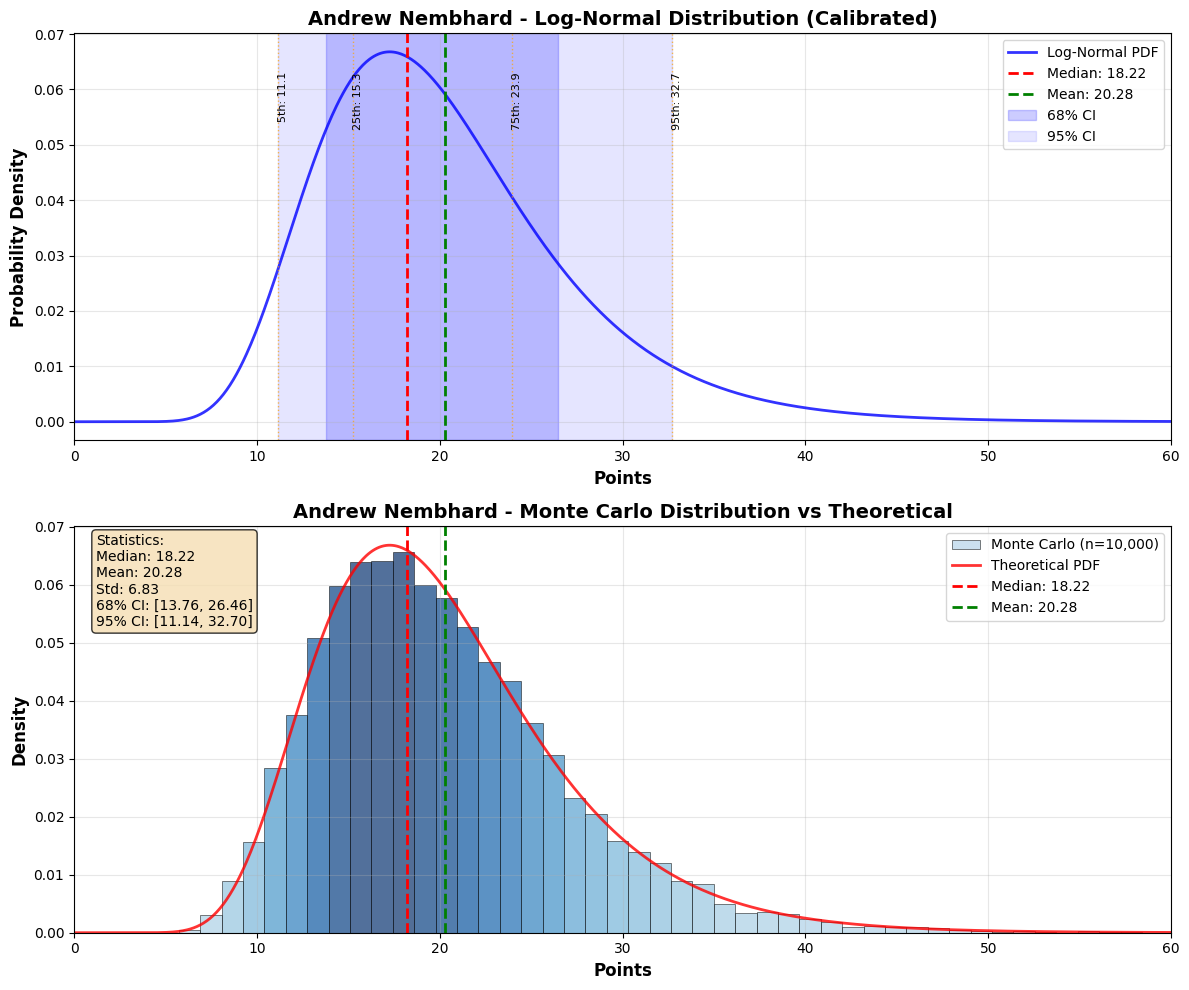

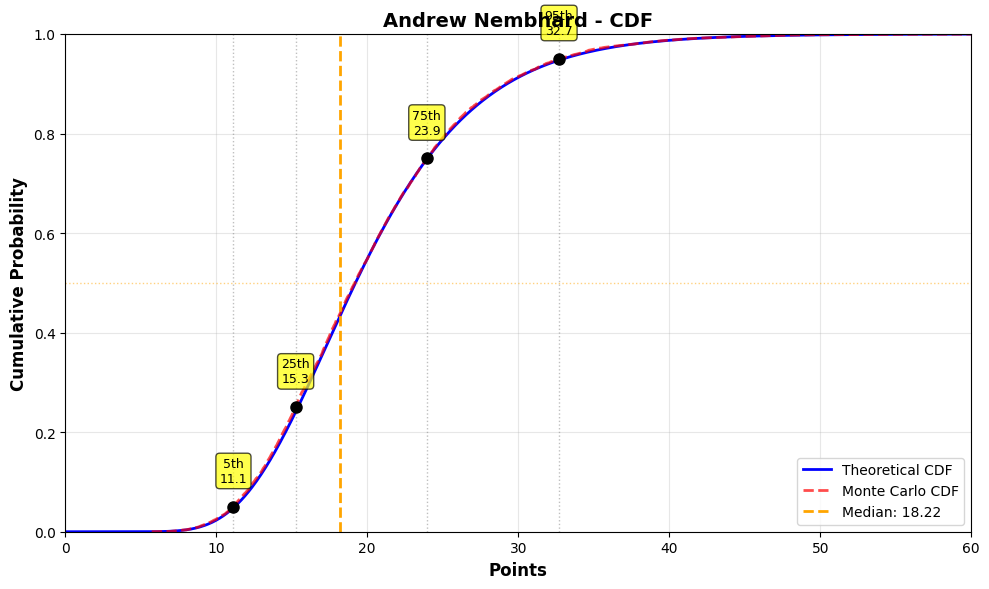

In [17]:
# Create figure with subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# ===== TOP PLOT: Theoretical PDF with Statistics =====
ax1 = axes[0]
x = np.linspace(0, max(60, np.percentile(samples, 99)), 1000)
pdf_values = distribution.pdf(x)

# Plot PDF
ax1.plot(x, pdf_values, 'b-', linewidth=2, label='Log-Normal PDF', alpha=0.8)

# Add vertical lines for key statistics
ax1.axvline(median_pred, color='r', linestyle='--', linewidth=2, label=f'Median: {median_pred:.2f}')
ax1.axvline(distribution.mean(), color='g', linestyle='--', linewidth=2, label=f'Mean: {distribution.mean():.2f}')

# Add confidence intervals
ci_68_low = np.percentile(samples, 16)
ci_68_high = np.percentile(samples, 84)
ci_95_low = np.percentile(samples, 5)
ci_95_high = np.percentile(samples, 95)

ax1.axvspan(ci_68_low, ci_68_high, alpha=0.2, color='blue', label='68% CI')
ax1.axvspan(ci_95_low, ci_95_high, alpha=0.1, color='blue', label='95% CI')

# Add percentiles
percentiles = [5, 25, 75, 95]
percentile_values = [np.percentile(samples, p) for p in percentiles]
percentile_labels = [f'{p}th: {v:.1f}' for p, v in zip(percentiles, percentile_values)]

for p_val, p_label in zip(percentile_values, percentile_labels):
    ax1.axvline(p_val, color='orange', linestyle=':', linewidth=1, alpha=0.7)
    ax1.text(p_val, ax1.get_ylim()[1] * 0.9, p_label, rotation=90, 
             verticalalignment='top', fontsize=8)

ax1.set_xlabel('Points', fontsize=12, fontweight='bold')
ax1.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax1.set_title(f'{name} - Log-Normal Distribution (Calibrated)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, max(60, np.percentile(samples, 99)))

# ===== BOTTOM PLOT: Monte Carlo Histogram =====
ax2 = axes[1]

# Create histogram from Monte Carlo samples
n_bins = 50
counts, bins, patches = ax2.hist(samples, bins=n_bins, density=True, alpha=0.7, 
                                  color='steelblue', edgecolor='black', linewidth=0.5,
                                  label=f'Monte Carlo (n={len(samples):,})')

# Overlay theoretical PDF
ax2.plot(x, pdf_values, 'r-', linewidth=2, label='Theoretical PDF', alpha=0.8)

# Add vertical lines for key statistics
ax2.axvline(median_pred, color='red', linestyle='--', linewidth=2, label=f'Median: {median_pred:.2f}')
ax2.axvline(distribution.mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: {distribution.mean():.2f}')

# Color bars by density (darker = more frequent)
max_count = max(counts)
for count, patch in zip(counts, patches):
    patch.set_facecolor(plt.cm.Blues(0.3 + 0.7 * count / max_count))

# Add text box with statistics
stats_text = f'''Statistics:
Median: {median_pred:.2f}
Mean: {distribution.mean():.2f}
Std: {distribution.std():.2f}
68% CI: [{ci_68_low:.2f}, {ci_68_high:.2f}]
95% CI: [{ci_95_low:.2f}, {ci_95_high:.2f}]'''

ax2.text(0.02, 0.98, stats_text, transform=ax2.transAxes, 
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax2.set_xlabel('Points', fontsize=12, fontweight='bold')
ax2.set_ylabel('Density', fontsize=12, fontweight='bold')
ax2.set_title(f'{name} - Monte Carlo Distribution vs Theoretical', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, max(60, np.percentile(samples, 99)))

plt.tight_layout()
plt.show()

# ===== Additional: CDF Plot =====
fig2, ax3 = plt.subplots(1, 1, figsize=(10, 6))

# Plot CDF
cdf_values = distribution.cdf(x)
ax3.plot(x, cdf_values, 'b-', linewidth=2, label='Theoretical CDF')

# Monte Carlo CDF (empirical)
sorted_samples = np.sort(samples)
mc_cdf = np.arange(1, len(sorted_samples) + 1) / len(sorted_samples)
ax3.plot(sorted_samples, mc_cdf, 'r--', linewidth=2, alpha=0.7, label='Monte Carlo CDF')

# Add median line
ax3.axvline(median_pred, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_pred:.2f}')
ax3.axhline(0.5, color='orange', linestyle=':', linewidth=1, alpha=0.5)

# Add percentile markers
for p, p_val in zip([5, 25, 75, 95], percentile_values):
    ax3.axvline(p_val, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    ax3.plot(p_val, p/100, 'ko', markersize=8)
    ax3.text(p_val, p/100 + 0.05, f'{p}th\n{p_val:.1f}', 
             ha='center', fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax3.set_xlabel('Points', fontsize=12, fontweight='bold')
ax3.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax3.set_title(f'{name} - CDF', fontsize=14, fontweight='bold')
ax3.legend(loc='lower right', fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, max(60, np.percentile(samples, 99)))
ax3.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [18]:
# Calculate probabilities using calibrated distribution
line = betting_line
prob_over = 1 - distribution.cdf(line)
prob_under = distribution.cdf(line)

if odds > 0:
    dec_odds = 1 + (odds / 100.0)
else:
    dec_odds = 1 + (100.0 / abs(odds))

# Calculate Expected Value using actual odds
ev_over = (prob_over * (dec_odds - 1)) - (1 - prob_over)
ev_under = (prob_under * (dec_odds - 1)) - (1 - prob_under)

# Determine recommendation
best_ev = max(ev_over, ev_under)
best_side = "OVER" if ev_over > ev_under else "UNDER"

print(f"\n{'='*60}")
print(f"BETTING ANALYSIS - Line: {line:.1f} | Odds: {odds:+d}")
print(f"{'='*60}")
print(f"Prediction: {median_pred:.2f} points")
print(f"Over {line:.1f}:  {prob_over:.1%} | EV: {ev_over:+.3f}")
print(f"Under {line:.1f}: {prob_under:.1%} | EV: {ev_under:+.3f}")
print(f"\n→ Recommendation: {best_side} {line:.1f} (EV: {best_ev:+.3f})")


BETTING ANALYSIS - Line: 16.5 | Odds: -137
Prediction: 18.22 points
Over 16.5:  67.9% | EV: +0.175
Under 16.5: 32.1% | EV: -0.445

→ Recommendation: OVER 16.5 (EV: +0.175)


In [19]:
# Filter for Underdog player points
# dfsPTS = dfsData[(dfsData['BOOKMAKER'] == 'Underdog') & (dfsData['CATEGORY'] == 'player_points')]
dfsPTS = dfsData[(dfsData['BOOKMAKER'] == 'PrizePicks') & (dfsData['CATEGORY'] == 'player_points')]


really_low_volume_lines = dfsPTS[dfsPTS['LINE'].between(4.5, 8.5)]
print(f"Really low volume lines (4.5-7.5): {len(really_low_volume_lines)} bets")

low_volume_lines = dfsPTS[dfsPTS['LINE'].between(8.5, 15.5)]
print(f"Low volume lines (8.5-15.5): {len(low_volume_lines)} bets")

mid_tier_lines = dfsPTS[dfsPTS['LINE'].between(15.5, 22.5)]
print(f"Mid-tier lines (15.5-22.5): {len(mid_tier_lines)} bets")

high_volume_lines = dfsPTS[dfsPTS['LINE'].between(22.5, 35.5)]
print(f"High volume lines (22.5-35.5): {len(high_volume_lines)} bets")

Really low volume lines (4.5-7.5): 16 bets
Low volume lines (8.5-15.5): 34 bets
Mid-tier lines (15.5-22.5): 28 bets
High volume lines (22.5-35.5): 10 bets


In [11]:
underdogPairs = calculate2LegBets(
    data=s26,
    bookmakers=really_low_volume_lines,
    engine=engine,
    current_date=current_date,
    top_n=10,                    # Get top 10 bets
    max_player_appearances=1,    # Each player appears max once
    projectedStartingFive=projectedStartingFive,
    mainStartingFive=mainStartingFive,
    teamStarPlayer=teamStarPlayer,
    league_df=league_df,
    findOpp=findOpp
)
underdogPairs

Computing predictions for 8 players...
[MIN] No data found for Herb Jones
Found 7 valid players
Generated 14 valid 2-leg combinations


,NAME 1,NAME 2,LINE 1,LINE 2,SIDE 1,SIDE 2,PREDICTION 1,PREDICTION 2,MODEL_PROB 1,MODEL_PROB 2,IMPLIED_PROB 1,IMPLIED_PROB 2,PARLAY_PROB,PARLAY_IMPLIED_PROB,PARLAY_EDGE,EDGE 1,EDGE 2,ODDS 1,ODDS 2,PARLAY_ODDS,PARLAY_DECIMAL,EV,EV_PERCENT,KELLY_QUARTER
0,Jarace Walker,Ryan Dunn,7.5,6.5,over,over,15.99,7.94,0.942,0.672,0.52,0.51,0.633,0.265,0.368,8.49,1.44,-114,-110,258,3.58,1.2678,126.78,0.1229
12,Oso Ighodaro,Jordan Hawkins,4.5,6.5,under,over,2.82,8.14,0.525,0.660,0.49,0.51,0.347,0.250,0.097,1.68,1.64,100,-108,285,3.85,0.3344,33.44,0.0293


In [12]:
underdogPairs = calculate2LegBets(
    data=s26,
    bookmakers=low_volume_lines,
    engine=engine,
    current_date=current_date,
    top_n=10,                    # Get top 10 bets
    max_player_appearances=1,    # Each player appears max once
    projectedStartingFive=projectedStartingFive,
    mainStartingFive=mainStartingFive,
    teamStarPlayer=teamStarPlayer,
    league_df=league_df,
    findOpp=findOpp
)
underdogPairs

Computing predictions for 17 players...
Found 17 valid players
Generated 94 valid 2-leg combinations


,NAME 1,NAME 2,LINE 1,LINE 2,SIDE 1,SIDE 2,PREDICTION 1,PREDICTION 2,MODEL_PROB 1,MODEL_PROB 2,IMPLIED_PROB 1,IMPLIED_PROB 2,PARLAY_PROB,PARLAY_IMPLIED_PROB,PARLAY_EDGE,EDGE 1,EDGE 2,ODDS 1,ODDS 2,PARLAY_ODDS,PARLAY_DECIMAL,EV,EV_PERCENT,KELLY_QUARTER
48,T.J. McConnell,Dylan Harper,9.5,12.5,over,over,18.76,16.96,0.948,0.807,0.49,0.48,0.766,0.235,0.531,9.26,4.46,100,102,304,4.04,2.0940,209.40,0.1722
33,Maxime Raynaud,Stephon Castle,12.0,14.5,under,over,4.63,16.48,0.882,0.656,0.56,0.44,0.579,0.246,0.333,7.37,1.98,-137,120,281,3.81,1.2067,120.67,0.1074
19,Malik Monk,Devin Vassell,13.5,15.5,over,over,15.00,18.59,0.621,0.697,0.48,0.52,0.433,0.250,0.183,1.50,3.09,102,-115,278,3.78,0.6353,63.53,0.0571
85,Rudy Gobert,Keldon Johnson,10.5,12.5,under,over,7.92,13.70,0.594,0.620,0.50,0.50,0.369,0.250,0.119,2.58,1.20,-103,-105,285,3.85,0.4188,41.88,0.0367
68,Donte DiVincenzo,Derik Queen,14.5,13.5,under,under,12.29,10.32,0.543,0.623,0.53,0.51,0.339,0.270,0.069,2.21,3.18,-120,-110,250,3.50,0.1859,18.59,0.0186
3,Russell Westbrook,Mark Williams,13.5,12.0,under,under,11.57,9.67,0.530,0.570,0.53,0.56,0.302,0.297,0.005,1.93,2.33,-117,-137,221,3.21,-0.0298,-2.98,0.0000
56,Jaden McDaniels,Harrison Barnes,15.5,12.5,under,under,13.99,11.53,0.501,0.464,0.50,0.52,0.233,0.260,-0.027,1.51,0.97,-107,-113,265,3.65,-0.1512,-15.12,0.0000
65,Naz Reid,Jose Alvarado,15.5,8.5,under,under,14.18,7.68,0.489,0.439,0.52,0.50,0.215,0.260,-0.045,1.32,0.82,-115,-105,265,3.65,-0.2156,-21.56,0.0000


In [13]:
underdogPairs = calculate2LegBets(
    data=s26,
    bookmakers=mid_tier_lines,
    engine=engine,
    current_date=current_date,
    top_n=10,                    # Get top 10 bets
    max_player_appearances=1,    # Each player appears max once
    projectedStartingFive=projectedStartingFive,
    mainStartingFive=mainStartingFive,
    teamStarPlayer=teamStarPlayer,
    league_df=league_df,
    findOpp=findOpp
)
underdogPairs

Computing predictions for 14 players...
Found 14 valid players
Generated 64 valid 2-leg combinations


,NAME 1,NAME 2,LINE 1,LINE 2,SIDE 1,SIDE 2,PREDICTION 1,PREDICTION 2,MODEL_PROB 1,MODEL_PROB 2,IMPLIED_PROB 1,IMPLIED_PROB 2,PARLAY_PROB,PARLAY_IMPLIED_PROB,PARLAY_EDGE,EDGE 1,EDGE 2,ODDS 1,ODDS 2,PARLAY_ODDS,PARLAY_DECIMAL,EV,EV_PERCENT,KELLY_QUARTER
54,Collin Gillespie,Saddiq Bey,17.0,16.5,under,under,9.73,12.29,0.757,0.675,0.56,0.50,0.511,0.280,0.231,7.27,4.21,-137,-107,235,3.35,0.7115,71.15,0.0757
51,Grayson Allen,Devin Vassell,18.5,15.5,under,over,14.24,18.59,0.665,0.697,0.50,0.52,0.463,0.260,0.203,4.26,3.09,-104,-115,267,3.67,0.7001,70.01,0.0656
30,Andrew Nembhard,Dillon Brooks,16.5,22.5,over,over,18.08,24.68,0.638,0.648,0.50,0.51,0.413,0.255,0.158,1.58,2.18,-103,-108,280,3.80,0.5712,57.12,0.0510
11,Zach LaVine,Julius Randle,21.5,22.5,under,under,18.57,19.15,0.580,0.618,0.53,0.51,0.359,0.270,0.088,2.93,3.35,-120,-109,252,3.52,0.2619,26.19,0.0260
6,Bennedict Mathurin,Trey Murphy III,21.5,21.5,under,under,19.51,19.27,0.527,0.540,0.49,0.50,0.285,0.245,0.040,1.99,2.23,-102,-105,287,3.87,0.1022,10.22,0.0089
24,DeMar DeRozan,Jaden McDaniels,18.5,15.5,under,under,17.13,13.99,0.492,0.501,0.48,0.50,0.247,0.240,0.007,1.37,1.51,105,-107,297,3.97,-0.0213,-2.13,0.0000
61,Naz Reid,Jeremiah Fears,15.5,16.5,under,under,14.18,15.50,0.489,0.467,0.52,0.50,0.228,0.260,-0.032,1.32,1.00,-115,-107,262,3.62,-0.1729,-17.29,0.0000


In [14]:
underdogPairs = calculate2LegBets(
    data=s26,
    bookmakers=high_volume_lines,
    engine=engine,
    current_date=current_date,
    top_n=10,                    # Get top 10 bets
    max_player_appearances=1,    # Each player appears max once
    projectedStartingFive=projectedStartingFive,
    mainStartingFive=mainStartingFive,
    teamStarPlayer=teamStarPlayer,
    league_df=league_df,
    findOpp=findOpp
)
underdogPairs

Computing predictions for 5 players...
Found 5 valid players
Generated 7 valid 2-leg combinations


,NAME 1,NAME 2,LINE 1,LINE 2,SIDE 1,SIDE 2,PREDICTION 1,PREDICTION 2,MODEL_PROB 1,MODEL_PROB 2,IMPLIED_PROB 1,IMPLIED_PROB 2,PARLAY_PROB,PARLAY_IMPLIED_PROB,PARLAY_EDGE,EDGE 1,EDGE 2,ODDS 1,ODDS 2,PARLAY_ODDS,PARLAY_DECIMAL,EV,EV_PERCENT,KELLY_QUARTER
3,Pascal Siakam,De'Aaron Fox,24.5,24.5,over,over,27.36,29.46,0.683,0.778,0.5,0.47,0.532,0.235,0.297,2.86,4.96,-104,108,308,4.08,1.1708,117.08,0.095
